# 05. Publication Figure 1: Positional Selection Decay Curves

## Visual Representation
Renders publication-ready decay curves contrasting the theoretical model saliency against observed human choice across `Ranked`, `Reverse`, and `Shuffled` regimes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/mnt/data/h2_testing_dataset.csv')

# Aggregations
decay_df = df.groupby(['condition', 'displayed_position'])['selected'].agg(
    mean='mean',
    std='std',
    count='count'
).reset_index()
decay_df['se'] = decay_df['std'] / np.sqrt(decay_df['count'])
decay_df['ci95'] = 1.96 * decay_df['se']


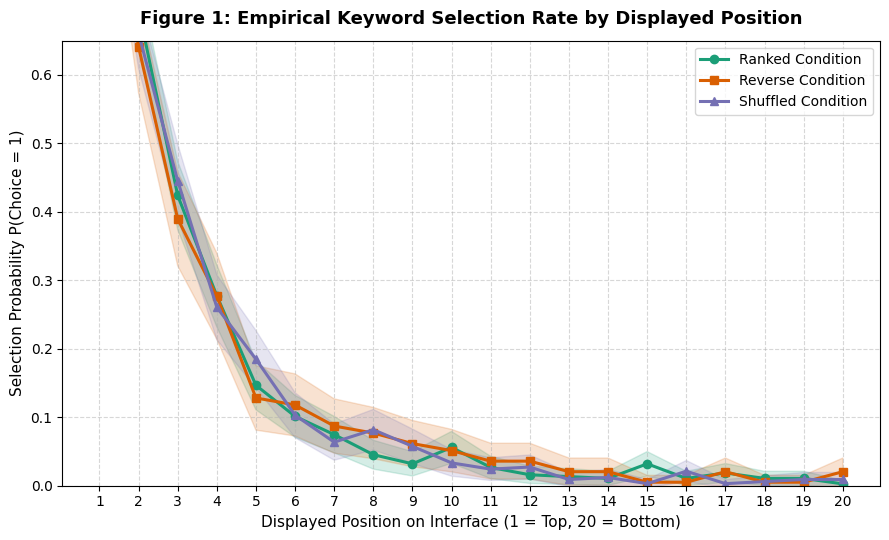

Figure 1 rendered and exported successfully.


In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = {'Ranked': '#1b9e77', 'Reverse': '#d95f02', 'Shuffled': '#7570b3'}
markers = {'Ranked': 'o', 'Reverse': 's', 'Shuffled': '^'}

for cond in ['Ranked', 'Reverse', 'Shuffled']:
    sub = decay_df[decay_df['condition'] == cond]
    ax.plot(sub['displayed_position'], sub['mean'], label=f"{cond} Condition", 
            color=colors[cond], marker=markers[cond], linewidth=2.2, markersize=6)
    ax.fill_between(sub['displayed_position'], sub['mean'] - sub['ci95'], sub['mean'] + sub['ci95'], 
                    color=colors[cond], alpha=0.18)

ax.set_title("Figure 1: Empirical Keyword Selection Rate by Displayed Position", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Displayed Position on Interface (1 = Top, 20 = Bottom)", fontsize=11)
ax.set_ylabel("Selection Probability P(Choice = 1)", fontsize=11)
ax.set_xticks(range(1, 21))
ax.set_ylim(0, 0.65)
ax.legend(frameon=True, loc='upper right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/mnt/data/github_replication_suite/notebooks/figure1_positional_decay.png', dpi=300)
plt.show()
print("Figure 1 rendered and exported successfully.")
